In [16]:

import re, unicodedata, textwrap, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu, pearsonr
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# ── Colour palette ────────────────────────────────────────────────────────────
PURPLE = '#534AB7'
TEAL   = '#0F6E56'
CORAL  = '#993C1D'
AMBER  = '#854F0B'
GRAY   = '#5F5E5A'
LBLUE  = '#378ADD'

MODEL_COLORS  = {'mbert': TEAL,   'xlmr': LBLUE,  'ro_bert': PURPLE, 'robert': AMBER}
MODEL_DISPLAY = {'mbert': 'mBERT','xlmr': 'XLM-R','ro_bert': 'RO-BERT','robert': 'RoBERT'}
MODEL_FAMILY  = {'mbert': 'Multilingual','xlmr': 'Multilingual',
                 'ro_bert': 'Monolingual','robert': 'Monolingual'}
MODEL_ORDER   = ['mbert','xlmr','ro_bert','robert']
FAMILY_COLOR  = {'Multilingual': TEAL, 'Monolingual': PURPLE}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 10,
})
Path('figures_rq1').mkdir(exist_ok=True)
FIG_FOLDER_RQ1 = 'figures_rq1'
Path('figures_rq2').mkdir(exist_ok=True)
FIG_FOLDER_RQ2 = 'figures_rq2'
Path('analysis_outputs').mkdir(exist_ok=True)
ANALYSIS_FOLDER = 'analysis_outputs'



# Load dataset


In [17]:

df_all = pd.read_csv('diacritics_dataset_small.csv')
df_all = df_all.rename(columns={
    'diacritics':    'text_diac',
    'no_diacritics': 'text_nodiac',
})

df_all['n_chars'] = df_all['text_nodiac'].str.len()
df_all['n_words'] = df_all['text_nodiac'].str.split().str.len()

# Count how many diacritic characters are present in the diacritics column
CORRECT_DIAC = set('ăâîșțĂÂÎȘȚ')
df_all['n_diac_restored'] = df_all['text_diac'].apply(
    lambda s: sum(1 for c in str(s) if c in CORRECT_DIAC)
)

print(f'\nDataset loaded: {len(df_all):,} sentence pairs')
print(f'Avg chars/sentence : {df_all["n_chars"].mean():.0f}')
print(f'Avg words/sentence : {df_all["n_words"].mean():.0f}')
print(f'Avg diacritics/sent: {df_all["n_diac_restored"].mean():.2f}')
print(f'Sentences with ≥1 diacritic: {(df_all["n_diac_restored"]>0).sum():,} '
      f'({(df_all["n_diac_restored"]>0).mean()*100:.1f}%)')
print()
print('Sample row:')
ex = df_all.nlargest(1,'n_diac_restored').iloc[0]
print(f'  NO-DIAC : {ex["text_nodiac"]}')
print(f'  DIAC    : {ex["text_diac"]}')
print(f'  Diacritics: {ex["n_diac_restored"]}')

df_filtered = df_all[(df_all['n_words'] >= 3) & (df_all['n_words'] <= 250)].copy().reset_index(drop=True)

TEXTS_NODIAC = df_filtered['text_nodiac'].tolist()
TEXTS_DIAC   = df_filtered['text_diac'].tolist()
N = len(TEXTS_NODIAC)




Dataset loaded: 10,000 sentence pairs
Avg chars/sentence : 138
Avg words/sentence : 22
Avg diacritics/sent: 7.39
Sentences with ≥1 diacritic: 9,442 (94.4%)

Sample row:
  NO-DIAC : Principiul e chestia, domnule! Nu pleci afara pina nu-ti cunosti tara si frumusetile ei de ticalosie! Asta e lege! Dar acum voi nu mai aveti nici un Dumnezeu! V-ati pierdut toate reperele, toate valorile! Cum sa pleci, cind tu nu stii ce-i aici? Cum sa te duci sa vizitezi un nenorocit de englez, cind avem aici oameni mari, care au depasit orice limite ale creatiei de ticalosie? Uite, stie cineva din lumea civilizata, care se bate cu caramida-n piept, ca aici, la noi, exista domni si doamne functionari care fura banii publici destinati bolnavilor in stare terminala? Ca exista domni si doamne care raporteaza cheltuieli fictive, ca minaresc importuri de medicamente, pina cind aia care le asteapta pot sa crape? Ca se raporteaza internari si tratamente fictive, ca sa se sifoneze banii cu pricina? Stie lumea asta


# Tokenizer models



In [18]:
MODEL_SPECS = {
    "mbert": {
        "display": "mBERT",
        "family": "Multilingual",
        "hf_id": "bert-base-multilingual-cased",
    },
    "xlmr": {
        "display": "XLM-R",
        "family": "Multilingual",
        "hf_id": "FacebookAI/xlm-roberta-base",
    },
    "ro_bert": {
        "display": "RO-BERT",
        "family": "Monolingual",
        "hf_id": "dumitrescustefan/bert-base-romanian-cased-v1",
    },
    "robert": {
        "display": "RoBERT",
        "family": "Monolingual",
        "hf_id": "readerbench/RoBERT-base",
    },
}


MODEL_DISPLAY = {k: v["display"] for k, v in MODEL_SPECS.items()}
MODEL_FAMILY = {k: v["family"] for k, v in MODEL_SPECS.items()}
MODEL_ORDER = ["mbert", "xlmr", "ro_bert", "robert"]

TOKENIZERS = {
    tag: AutoTokenizer.from_pretrained(spec["hf_id"], use_fast=True)
    for tag, spec in MODEL_SPECS.items()
}
DEVICE = "cpu"
MODELS = {
    tag: AutoModel.from_pretrained(spec["hf_id"]).to(DEVICE).eval()
    for tag, spec in MODEL_SPECS.items()
}
for tag, tokenizer in TOKENIZERS.items():
    print(f"{MODEL_DISPLAY[tag]:10} -> {MODEL_SPECS[tag]['hf_id']}")
    print(f"  vocab size: {tokenizer.vocab_size}")
    print(f"  unk token : {tokenizer.unk_token}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6597.42it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7534.86it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status

mBERT      -> bert-base-multilingual-cased
  vocab size: 119547
  unk token : [UNK]
XLM-R      -> FacebookAI/xlm-roberta-base
  vocab size: 250002
  unk token : <unk>
RO-BERT    -> dumitrescustefan/bert-base-romanian-cased-v1
  vocab size: 50000
  unk token : [UNK]
RoBERT     -> readerbench/RoBERT-base
  vocab size: 37788
  unk token : [UNK]


In [19]:
def hf_tokenize(sentence, tokenizer):
    """
    Tokenize full text for tokenizer-level analysis.
    """
    old_max_len = tokenizer.model_max_length

    try:
        tokenizer.model_max_length = int(1e9)

        encoded = tokenizer(
            str(sentence),
            add_special_tokens=False,
            truncation=False,
            return_attention_mask=False,
            return_token_type_ids=False,
            verbose=False,
        )

        return tokenizer.convert_ids_to_tokens(encoded["input_ids"])

    finally:
        tokenizer.model_max_length = old_max_len


def count_unk(tokens, tokenizer):
    if tokenizer.unk_token is None:
        return 0
    return sum(tok == tokenizer.unk_token for tok in tokens)


def clean_subword_token(tok):
    tok = tok.replace("##", "")
    tok = tok.replace("▁", "")
    tok = tok.replace("Ġ", "")
    return tok.strip()


def single_char_rate(tokens, tokenizer):
    cleaned = [
        clean_subword_token(tok)
        for tok in tokens
        if tok not in tokenizer.all_special_tokens
    ]

    cleaned = [tok for tok in cleaned if tok != ""]

    if not cleaned:
        return 0.0

    single = sum(1 for tok in cleaned if len(tok) == 1)
    return single / len(cleaned)


# SECTION 4 — Tokenize all sentences × 4 models × 2 conditions


In [20]:
rows = []

for i, (sent_nd, sent_d) in enumerate(zip(TEXTS_NODIAC, TEXTS_DIAC)):
    n_words = len(str(sent_nd).split())
    n_diac = df_filtered.iloc[i]["n_diac_restored"]

    for tag, tokenizer in TOKENIZERS.items():
        toks_nd = hf_tokenize(sent_nd, tokenizer)
        toks_d = hf_tokenize(sent_d, tokenizer)

        cnt_nd = len(toks_nd)
        cnt_d = len(toks_d)

        rows.append({
            "sent_idx": i,
            "model": tag,
            # "hf_id": MODEL_SPECS[tag]["hf_id"],
            "family": MODEL_FAMILY[tag],
            "n_words": n_words,
            "n_diac": n_diac,

            "tokens_nd": cnt_nd,
            "fertility_nd": cnt_nd / max(n_words, 1),
            "unk_nd": count_unk(toks_nd, tokenizer),
            "scr_nd": single_char_rate(toks_nd, tokenizer),

            "tokens_d": cnt_d,
            "fertility_d": cnt_d / max(n_words, 1),
            "unk_d": count_unk(toks_d, tokenizer),
            "scr_d": single_char_rate(toks_d, tokenizer),

            "delta_tokens": cnt_d - cnt_nd,
            "inflation": (cnt_d - cnt_nd) / max(cnt_nd, 1),
        })

df = pd.DataFrame(rows)

print(f"\nRecords: {len(df)} ({N} sentences × {len(TOKENIZERS)} models)")
print(df.head())


Records: 39448 (9862 sentences × 4 models)
   sent_idx    model        family  n_words  n_diac  tokens_nd  fertility_nd  \
0         0    mbert  Multilingual       11       1         18      1.636364   
1         0     xlmr  Multilingual       11       1         15      1.363636   
2         0  ro_bert   Monolingual       11       1         16      1.454545   
3         0   robert   Monolingual       11       1         18      1.636364   
4         1    mbert  Multilingual       11       3         16      1.454545   

   unk_nd    scr_nd  tokens_d  fertility_d  unk_d     scr_d  delta_tokens  \
0       0  0.166667        19     1.727273      0  0.210526             1   
1       0  0.133333        15     1.363636      0  0.133333             0   
2       0  0.250000        16     1.454545      0  0.250000             0   
3       0  0.277778        18     1.636364      0  0.277778             0   
4       0  0.062500        16     1.454545      0  0.125000             0   

   inflation

In [21]:


summary = df.groupby("model").agg(
    avg_tokens_nd=("tokens_nd", "mean"),
    avg_tokens_d=("tokens_d", "mean"),
    avg_fert_nd=("fertility_nd", "mean"),
    avg_fert_d=("fertility_d", "mean"),
    avg_unk_nd=("unk_nd", "mean"),
    avg_unk_d=("unk_d", "mean"),
    avg_scr_nd=("scr_nd", "mean"),
    avg_scr_d=("scr_d", "mean"),
    avg_delta=("delta_tokens", "mean"),
    avg_inflation=("inflation", "mean"),
).round(4).reset_index()

summary["display"] = summary["model"].map(MODEL_DISPLAY)
summary["family"] = summary["model"].map(MODEL_FAMILY)
# summary["hf_id"] = summary["model"].map(lambda m: MODEL_SPECS[m]["hf_id"])

summary = summary[[
    "model", "display", "family",
    "avg_tokens_nd", "avg_tokens_d",
    "avg_fert_nd", "avg_fert_d",
    "avg_unk_nd", "avg_unk_d",
    "avg_scr_nd", "avg_scr_d",
    "avg_delta", "avg_inflation"
]]

print(summary)
summary.to_csv(f'{ANALYSIS_FOLDER}/rq1_summary_tokenizers.csv', index=False)

     model  display        family  avg_tokens_nd  avg_tokens_d  avg_fert_nd  \
0    mbert    mBERT  Multilingual        41.9856       43.6654       1.9536   
1  ro_bert  RO-BERT   Monolingual        32.1889       30.9678       1.5226   
2   robert   RoBERT   Monolingual        36.1893       35.8707       1.6680   
3     xlmr    XLM-R  Multilingual        35.9086       37.4984       1.6865   

   avg_fert_d  avg_unk_nd  avg_unk_d  avg_scr_nd  avg_scr_d  avg_delta  \
0      2.0599      0.1342     0.1391      0.2301     0.2698     1.6798   
1      1.4712      0.0378     0.0387      0.2196     0.2177    -1.2212   
2      1.6539      0.0054     0.0055      0.2358     0.2359    -0.3186   
3      1.7790      0.0000     0.0000      0.2149     0.2278     1.5897   

   avg_inflation  
0         0.0523  
1        -0.0340  
2        -0.0081  
3         0.0523  


In [22]:
def get_target_word_embedding(sentence, target_start, target_end, tokenizer, model):
    """
    Extracts contextual embedding for a target word using character offsets.
    """

    encoded = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=512,
        add_special_tokens=True,
    )

    offsets = encoded.pop("offset_mapping")[0].tolist()

    encoded = {
        k: v.to(DEVICE)
        for k, v in encoded.items()
    }

    target_token_indices = []

    for idx, (start, end) in enumerate(offsets):
        if start == end:
            continue  # special token

        overlaps = not (end <= target_start or start >= target_end)
        if overlaps:
            target_token_indices.append(idx)

    if not target_token_indices:
        return None

    with torch.no_grad():
        outputs = model(**encoded)
        hidden = outputs.last_hidden_state[0]  # shape: [seq_len, hidden_size]

    emb = hidden[target_token_indices].mean(dim=0)
    
    return emb.detach().cpu().numpy()

# SECTION 5 — Vocabulary overlap

In [23]:
vocab_stats = []

for tag, tokenizer in TOKENIZERS.items():
    all_nd = []
    all_d = []
    jaccard_sents = []

    for s_nd, s_d in zip(TEXTS_NODIAC, TEXTS_DIAC):
        t_nd = hf_tokenize(s_nd, tokenizer)
        t_d = hf_tokenize(s_d, tokenizer)

        all_nd.extend(t_nd)
        all_d.extend(t_d)

        set_nd = set(t_nd)
        set_d = set(t_d)

        union = set_nd | set_d
        jaccard = len(set_nd & set_d) / len(union) if union else 1.0
        jaccard_sents.append(jaccard)

    vocab_nd = set(all_nd)
    vocab_d = set(all_d)
    shared = vocab_nd & vocab_d

    vocab_stats.append({
        "model": tag,
        "display": MODEL_DISPLAY[tag],
        "family": MODEL_FAMILY[tag],
        # "hf_id": MODEL_SPECS[tag]["hf_id"],
        "vocab_nd": len(vocab_nd),
        "vocab_d": len(vocab_d),
        "shared": len(shared),
        "only_nd": len(vocab_nd - vocab_d),
        "only_d": len(vocab_d - vocab_nd),
        "overlap_pct": round(len(shared) / len(vocab_nd | vocab_d) * 100, 2),
        "mean_jaccard": round(np.mean(jaccard_sents), 4),
        "std_jaccard": round(np.std(jaccard_sents), 4),
    })

vocab_df = pd.DataFrame(vocab_stats)

print(vocab_df[[
    "display", "family",
    "vocab_nd", "vocab_d", "shared",
    "only_nd", "only_d", "overlap_pct",
    "mean_jaccard", "std_jaccard",
]])
print("=" * 85)

vocab_df.to_csv(f'{ANALYSIS_FOLDER}/rq1_vocab_overlap_tokenizers.csv', index=False)

   display        family  vocab_nd  vocab_d  shared  only_nd  only_d  \
0    mBERT  Multilingual     12046    11662   11113      933     549   
1    XLM-R  Multilingual     16329    15881   14756     1573    1125   
2  RO-BERT   Monolingual     22584    28269   20033     2551    8236   
3   RoBERT   Monolingual     16541    19612   15045     1496    4567   

   overlap_pct  mean_jaccard  std_jaccard  
0        88.23        0.6235       0.1583  
1        84.54        0.6141       0.1605  
2        65.00        0.5997       0.1641  
3        71.28        0.6406       0.1600  



# Generate some figures


In [24]:
import os
# ── Figure 1: Token count distributions ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
# FIG_FOLDER='new_figs'
# if not os.path.exists(FIG_FOLDER):
#     os.makedirs(FIG_FOLDER)
for ax, (condition, col) in zip(axes, [
    ('No-diacritics', 'tokens_nd'),
    ('With diacritics', 'tokens_d'),
]):
    data = [df[df['model']==m][col].values for m in MODEL_ORDER]
    parts = ax.violinplot(data, positions=range(4),
                          showmedians=True, showextrema=True, widths=0.65)
    for pc, m in zip(parts['bodies'], MODEL_ORDER):
        pc.set_facecolor(MODEL_COLORS[m]); pc.set_alpha(0.72); pc.set_edgecolor('white')
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2.5)
    for k in ['cmins','cmaxes','cbars']:
        parts[k].set_color(GRAY); parts[k].set_linewidth(0.8)

    means = [df[df['model']==m][col].mean() for m in MODEL_ORDER]
    ax.scatter(range(4), means, color='white', s=45, zorder=5,
               edgecolors=GRAY, linewidths=1.2)
    for i, (m, mn) in enumerate(zip(MODEL_ORDER, means)):
        ax.text(i, mn + 1.5, f'{mn:.1f}', ha='center', fontsize=8.5,
                color=MODEL_COLORS[m], fontweight='500')

    ax.set_xticks(range(4))
    ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
    ax.set_ylabel('Token count per sentence', fontsize=10)
    ax.set_title(condition, fontsize=11)
    ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)
    ax.text(0.5,  ax.get_ylim()[1]*0.97, 'Multilingual', ha='center',
            color=TEAL,   fontsize=8.5, style='italic')
    ax.text(2.5,  ax.get_ylim()[1]*0.97, 'Monolingual',  ha='center',
            color=PURPLE, fontsize=8.5, style='italic')

fig.suptitle(
    'Token Count Distributions: Multilingual vs Monolingual\n'
    'White dot = mean  |  White bar = median',
    fontsize=12, fontweight='500'
)
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ1}/rq1_fig1_token_distributions.png', dpi=150, bbox_inches='tight')
plt.close()
print('Figure 1 saved')

# ── Figure 2: Fertility grouped bar ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(4); w = 0.35

fert_nd     = [df[df['model']==m]['fertility_nd'].mean() for m in MODEL_ORDER]
fert_d      = [df[df['model']==m]['fertility_d'].mean()  for m in MODEL_ORDER]
fert_nd_std = [df[df['model']==m]['fertility_nd'].std()  for m in MODEL_ORDER]
fert_d_std  = [df[df['model']==m]['fertility_d'].std()   for m in MODEL_ORDER]

b1 = ax.bar(x - w/2, fert_nd, w, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
            alpha=0.88, edgecolor='white', label='No diacritics')
b2 = ax.bar(x + w/2, fert_d,  w, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
            alpha=0.45, edgecolor='white', hatch='..', label='Diacritics')
ax.errorbar(x-w/2, fert_nd, yerr=fert_nd_std, fmt='none', color=GRAY, capsize=4, lw=1.2)
ax.errorbar(x+w/2, fert_d,  yerr=fert_d_std,  fmt='none', color=GRAY, capsize=4, lw=1.2)

for bar, val in zip(list(b1)+list(b2), fert_nd+fert_d):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.2f}', ha='center', fontsize=8.5, color=GRAY)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=11)
ax.set_ylabel('Fertility (tokens per word)', fontsize=10)
ax.set_title(
    'Figure 2 — Fertility Rate per Model and Condition\n',
    fontsize=12
)
ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)

legend_patches = [
    mpatches.Patch(facecolor=GRAY, alpha=0.88, label="No diacritics"),
    mpatches.Patch(facecolor=GRAY, alpha=0.45, hatch="..", label="With diacritics"),
]
ax.legend(handles=legend_patches, fontsize=9, loc="upper right")
ax.legend(handles=legend_patches, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ1}/rq1_fig2_fertility.png', dpi=150, bbox_inches='tight')
plt.close()
print('Figure 2 saved')

# ── Figure 3: Token inflation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
# fig,ax = plt.subplots(figsize=(11, 5))
infl_means = [df[df['model']==m]['inflation'].mean()*100 for m in MODEL_ORDER]
infl_stds  = [df[df['model']==m]['inflation'].std()*100  for m in MODEL_ORDER]

bars = ax.bar(MODEL_ORDER, infl_means, yerr=infl_stds, capsize=5,
              color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.85, edgecolor='white')
ax.axhline(0, color=GRAY, lw=0.8)
for bar, val, std in zip(bars, infl_means, infl_stds):
    y = val + std + 0.3 if val >= 0 else val - std - 1.5
    ax.text(bar.get_x()+bar.get_width()/2, y, f'{val:+.2f}%',
            ha='center', fontsize=9, fontweight='500',
            color=MODEL_COLORS[MODEL_ORDER[list(bars).index(bar)]])
ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
ax.set_ylabel('Token inflation rate (%)\nwhen diacritics added')
ax.set_title('A — Mean Inflation: Diac vs No-Diac\n(+ = diac adds tokens; − = diac reduces tokens)')
ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)

ax = axes[1]
data_infl = [df[df['model']==m]['inflation'].values*100 for m in MODEL_ORDER]
parts = ax.violinplot(data_infl, positions=range(4),
                      showmedians=True, showextrema=True, widths=0.6)
for pc, m in zip(parts['bodies'], MODEL_ORDER):
    pc.set_facecolor(MODEL_COLORS[m]); pc.set_alpha(0.70); pc.set_edgecolor('white')
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
for k in ['cmins','cmaxes','cbars']:
    parts[k].set_color(GRAY); parts[k].set_linewidth(0.8)
ax.axhline(0, color=GRAY, lw=0.8, ls='--', alpha=0.6)
ax.set_xticks(range(4))
ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
ax.set_ylabel('Per-sentence inflation (%) — diac vs no-diac')
ax.set_title('B — Inflation Distribution\n(above zero = diac adds tokens)')
ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)

fig.suptitle('Token Inflation: Effect of Diacritics on Token Counts', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ1}/rq1_fig3_inflation.png', dpi=150, bbox_inches='tight')
plt.close()

# ── Figure 4: SCR and UNK ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(4); w = 0.35

for ax, (metric_nd, metric_d, ylabel, title) in zip(axes, [
    ('scr_nd', 'scr_d', 'Single-char token rate',
     'A — Over-segmentation (SCR)\nHigher = more fragmentation'),
    ('unk_nd', 'unk_d', 'Average [UNK] tokens per sentence',
     'B — UNK Token Rate\nRO-BERT: cedilla chars → [UNK]'),
]):
    nd_vals = [df[df['model']==m][metric_nd].mean() for m in MODEL_ORDER]
    d_vals  = [df[df['model']==m][metric_d].mean()  for m in MODEL_ORDER]

    b1 = ax.bar(x-w/2, nd_vals, w, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
                alpha=0.88, edgecolor='white', label='No diacritics')
    b2 = ax.bar(x+w/2, d_vals,  w, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
                alpha=0.45, edgecolor='white', hatch='..', label='Diacritics')
    for bar, val in zip(list(b1)+list(b2), nd_vals+d_vals):
        if val > 0.002:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height() + max(nd_vals+d_vals)*0.01,
                    f'{val:.3f}' if max(nd_vals+d_vals)<1 else f'{val:.2f}',
                    ha='center', fontsize=7.5, color=GRAY)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)
    ax.legend(fontsize=9)

fig.suptitle('Over-segmentation and UNK Rate', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ1}/rq1_fig4_scr_unk.png', dpi=150, bbox_inches='tight')
plt.close()
print('Figure 4 saved')

# ── Figure 5: Vocabulary overlap ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
x = np.arange(4)

shared_v  = [vocab_df[vocab_df['model']==m]['shared'].values[0]  for m in MODEL_ORDER]
only_nd_v = [vocab_df[vocab_df['model']==m]['only_nd'].values[0] for m in MODEL_ORDER]
only_d_v  = [vocab_df[vocab_df['model']==m]['only_d'].values[0]  for m in MODEL_ORDER]

ax.bar(x, shared_v,  0.55, label='Shared (both conditions)', color=TEAL,  alpha=0.85, edgecolor='white')
ax.bar(x, only_nd_v, 0.55, bottom=shared_v,
       label='Only in no-diac', color=CORAL, alpha=0.80, edgecolor='white')
btm2 = [s+n for s,n in zip(shared_v, only_nd_v)]
ax.bar(x, only_d_v,  0.55, bottom=btm2,
       label='Only in diac',    color=AMBER, alpha=0.75, edgecolor='white')

for i, m in enumerate(MODEL_ORDER):
    pct   = vocab_df[vocab_df['model']==m]['overlap_pct'].values[0]
    total = shared_v[i]+only_nd_v[i]+only_d_v[i]
    ax.text(i, total+50, f'{pct:.0f}%\noverlap',
            ha='center', fontsize=9, color=MODEL_COLORS[m], fontweight='500')

ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
ax.set_ylabel('Distinct token types')
ax.set_title('A — Vocabulary Composition')
ax.legend(fontsize=9)
ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)

ax = axes[1]
jacc_records = []

for tag, tokenizer in TOKENIZERS.items():
    jaccards = []

    for i in range(N):
        t_nd = set(hf_tokenize(TEXTS_NODIAC[i], tokenizer))
        t_d = set(hf_tokenize(TEXTS_DIAC[i], tokenizer))

        union = t_nd | t_d
        j = len(t_nd & t_d) / len(union) if union else 1.0
        jaccards.append(j)

    med = df_filtered["n_diac_restored"].median()

    for grp, label in [
        (df_filtered["n_diac_restored"] <= med, "Low diacritic density"),
        (df_filtered["n_diac_restored"] > med, "High diacritic density"),
    ]:
        idxs = df_filtered[grp].index.tolist()

        jacc_records.append({
            "model": MODEL_DISPLAY[tag],
            "group": label,
            "jaccard": np.mean([jaccards[i] for i in idxs if i < len(jaccards)]),
        })

jacc_df2 = pd.DataFrame(jacc_records)

pivot = jacc_df2.pivot(index="model", columns="group", values="jaccard")
pivot = pivot.loc[[MODEL_DISPLAY[m] for m in MODEL_ORDER]]

jacc_df2 = pd.DataFrame(jacc_records)
pivot    = jacc_df2.pivot(index='model', columns='group', values='jaccard')
pivot    = pivot.loc[[MODEL_DISPLAY[m] for m in MODEL_ORDER]]

sns.heatmap(pivot, ax=ax, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink':0.8, 'label':'Jaccard similarity'},
            annot_kws={'fontsize':11})
ax.set_title('B — Jaccard by Diacritic Density\n(no-diac vs diac token sets)')
ax.set_xlabel('Diacritic density group'); ax.set_ylabel('Model')
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=9)

fig.suptitle('Vocabulary Overlap: No-Diacritic vs Diacritic', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ1}/rq1_fig5_vocab_overlap.png', dpi=150, bbox_inches='tight')
plt.close()
print('Figure 5 saved')

# ── Figure 6: Diacritic density vs token count delta ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_flat = axes.flatten()

for ax_idx, tag in enumerate(MODEL_ORDER):
    ax  = axes_flat[ax_idx]
    sub = df[df['model']==tag].copy()
    x_v = sub['n_diac'].values
    y_v = sub['delta_tokens'].values

    ax.scatter(x_v, y_v, color=MODEL_COLORS[tag], alpha=0.35, s=18, edgecolors='none')

    if len(np.unique(x_v)) > 1:
        z = np.polyfit(x_v, y_v, 1)
        x_line = np.linspace(x_v.min(), x_v.max(), 50)
        ax.plot(x_line, np.poly1d(z)(x_line), color=MODEL_COLORS[tag], lw=2)
        r, p = pearsonr(x_v, y_v)
        sig = '*' if p < 0.05 else ''
        ax.text(0.04, 0.93, f'r = {r:.3f}{sig}', transform=ax.transAxes,
                fontsize=9, color=MODEL_COLORS[tag],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.axhline(0, color=GRAY, lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Diacritics in sentence (count)')
    ax.set_ylabel('Δ tokens (diac − no-diac)')
    ax.set_title(f'{MODEL_DISPLAY[tag]} ({MODEL_FAMILY[tag]})',
                 color=MODEL_COLORS[tag], fontsize=11)

fig.suptitle('Diacritic Density vs Token Count Delta\n',fontsize=12, fontweight='500'
)
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ1}/rq1_fig6_density_correlation.png', dpi=150, bbox_inches='tight')
plt.close()
print('Figure 6 saved')



Figure 1 saved
Figure 2 saved
Figure 4 saved
Figure 5 saved
Figure 6 saved


In [25]:

# ── Figure 3: Token inflation ─────────────────────────────────────────────────

fig,ax = plt.subplots(figsize=(7,5))
infl_means = [df[df['model']==m]['inflation'].mean()*100 for m in MODEL_ORDER]
infl_stds  = [df[df['model']==m]['inflation'].std()*100  for m in MODEL_ORDER]

bars = ax.bar(MODEL_ORDER, infl_means, yerr=infl_stds, capsize=5,
              color=[MODEL_COLORS[m] for m in MODEL_ORDER], alpha=0.85, edgecolor='white')
ax.axhline(0, color=GRAY, lw=0.8)
for bar, val, std in zip(bars, infl_means, infl_stds):
    y = val + std + 0.3 if val >= 0 else val - std - 1.5
    ax.text(bar.get_x()+bar.get_width()/2, y, f'{val:+.2f}%',
            ha='center', fontsize=9, fontweight='500',
            color=MODEL_COLORS[MODEL_ORDER[list(bars).index(bar)]])
ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
ax.set_ylabel('Token inflation rate (%)\nwhen diacritics added')
ax.set_title('A — Mean Inflation: Diac vs No-Diac\n(+ = diac adds tokens; − = diac reduces tokens)')
ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)

fig.suptitle('Token Inflation: Effect of Diacritics on Token Counts', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ1}/rq1_fig3_inflation.png', dpi=150, bbox_inches='tight')
plt.close()


# Results table + key findings


In [26]:

multi_nd = summary[summary['model'].isin(['mbert','xlmr'])]['avg_tokens_nd'].mean()
mono_nd  = summary[summary['model'].isin(['ro_bert','robert'])]['avg_tokens_nd'].mean()
inflation_pct = (multi_nd - mono_nd) / mono_nd * 100
multi_fert = summary[summary['model'].isin(['mbert','xlmr'])]['avg_fert_nd'].mean()
mono_fert  = summary[summary['model'].isin(['ro_bert','robert'])]['avg_fert_nd'].mean()
multi_ovlp = vocab_df[vocab_df['family']=='Multilingual']['overlap_pct'].mean()
mono_ovlp  = vocab_df[vocab_df['family']=='Monolingual']['overlap_pct'].mean()
multi_jacc = vocab_df[vocab_df['family']=='Multilingual']['mean_jaccard'].mean()
mono_jacc  = vocab_df[vocab_df['family']=='Monolingual']['mean_jaccard'].mean()

final_rows = []
for m in MODEL_ORDER:
    s = summary[summary['model']==m].iloc[0]
    v = vocab_df[vocab_df['model']==m].iloc[0]
    final_rows.append({
        'Model':            MODEL_DISPLAY[m],
        'Family':           MODEL_FAMILY[m],
        'Avg Tok [nd]':     round(s['avg_tokens_nd'], 2),
        'Avg Tok [d]':      round(s['avg_tokens_d'],  2),
        'Fertility [nd]':   round(s['avg_fert_nd'],   3),
        'Fertility [d]':    round(s['avg_fert_d'],    3),
        'UNK [nd]':         round(s['avg_unk_nd'],    3),
        'SCR [nd]':         round(s['avg_scr_nd'],    4),
        'Vocab overlap %':  round(v['overlap_pct'],   1),
        'Jaccard':          round(v['mean_jaccard'],  4),
        'Inflation %': round(s['avg_inflation']*100, 2),
    })

final_df = pd.DataFrame(final_rows)

print()
print('RQ1 — COMPLETE RESULTS TABLE')
print('═'*80)

print(final_df.to_string(index=False))

final_df.to_csv(f'{ANALYSIS_FOLDER}/rq1_results_table.csv', index=False)
vocab_df.to_csv(f'{ANALYSIS_FOLDER}/rq1_vocab_overlap_tokenizers.csv', index=False)
summary.to_csv(f'{ANALYSIS_FOLDER}/rq1_summary.csv', index=False)
df.to_csv(f'{ANALYSIS_FOLDER}/rq1_per_sentence_tokenization.csv', index=False)



RQ1 — COMPLETE RESULTS TABLE
════════════════════════════════════════════════════════════════════════════════
  Model       Family  Avg Tok [nd]  Avg Tok [d]  Fertility [nd]  Fertility [d]  UNK [nd]  SCR [nd]  Vocab overlap %  Jaccard  Inflation %
  mBERT Multilingual         41.99        43.67           1.954          2.060     0.134    0.2301             88.2   0.6235         5.23
  XLM-R Multilingual         35.91        37.50           1.686          1.779     0.000    0.2149             84.5   0.6141         5.23
RO-BERT  Monolingual         32.19        30.97           1.523          1.471     0.038    0.2196             65.0   0.5997        -3.40
 RoBERT  Monolingual         36.19        35.87           1.668          1.654     0.005    0.2358             71.3   0.6406        -0.81


# RQ2 – Embedding Robustness
## To what extent do LMs produce similar contextual embeddings for sentences with correct diacritics vs. without, and does this differ between multilingual and monolingual models?

**Dataset:** `diacritics_dataset_small.csv` — 10,000 Romanian sentence pairs (same dataset as RQ1)  
**Models:** mBERT · XLM-R · RO-BERT · RoBERT  

---

In [27]:
from scipy.stats import pearsonr, spearmanr, kendalltau, mannwhitneyu
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

import torch

Path('figures_rq2').mkdir(exist_ok=True)


The dataset and the models are already loaded

---
## Embedding Extraction

For every sentence pair we extract two types of embeddings:
- **CLS embedding** — the `[CLS]` / `<s>` token at position 0; the standard sentence-level representation
- **Mean-pool embedding** — average of all non-special token hidden states; less position-biased

In [28]:

@torch.no_grad()
def get_sentence_embedding(sentence: str, tag: str, layer: int = -1) -> dict:
    """
    Extract CLS and mean-pool sentence embeddings from a single layer.
    """
    tokenizer = TOKENIZERS[tag]
    model     = MODELS[tag]

    inputs = tokenizer(
        str(sentence),
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=False,
        add_special_tokens=True,
    ).to(DEVICE)

    outputs = model(**inputs, output_hidden_states=True)
    hidden  = outputs.hidden_states[layer]   # (1, seq_len, hidden_dim)

    # CLS token (position 0)
    cls_emb = hidden[0, 0, :].cpu().numpy()

    # Mean-pool over non-special tokens using attention mask
    mask    = inputs['attention_mask'][0].unsqueeze(-1).float()  # (seq_len, 1)
    # zero out first and last positions (special tokens)
    mask[0]  = 0.0
    mask[-1] = 0.0
    mean_emb = (hidden[0] * mask).sum(0) / mask.sum().clamp(min=1e-9)
    mean_emb = mean_emb.cpu().numpy()

    return {'cls': cls_emb, 'mean': mean_emb}


@torch.no_grad()
def get_target_word_embedding(
    sentence: str, target_start: int, target_end: int, tag: str
) -> np.ndarray | None:
    """
    Extract the contextual embedding for a target word span (character offsets).
    """
    tokenizer = TOKENIZERS[tag]
    model     = MODELS[tag]

    encoded = tokenizer(
        sentence,
        return_tensors='pt',
        return_offsets_mapping=True,
        truncation=True,
        max_length=512,
        add_special_tokens=True,
    )
    offsets = encoded.pop('offset_mapping')[0].tolist()
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

    token_indices = [
        i for i, (s, e) in enumerate(offsets)
        if s < e and not (e <= target_start or s >= target_end)
    ]
    if not token_indices:
        return None

    outputs = model(**encoded)
    hidden  = outputs.last_hidden_state[0]   # (seq_len, hidden_dim)
    emb     = hidden[token_indices].mean(dim=0)
    return emb.detach().cpu().numpy()


@torch.no_grad()
def get_layer_embeddings(
    sentence: str, tag: str, n_layers: int = 13
) -> list:
    """
    Return CLS embeddings from all hidden layers (0 = embedding layer, 1-12 = transformer blocks).
    """
    tokenizer = TOKENIZERS[tag]
    model     = MODELS[tag]

    inputs = tokenizer(
        str(sentence),
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=False,
    ).to(DEVICE)

    outputs = model(**inputs, output_hidden_states=True)
    # hidden_states is a tuple of (n_layers+1) tensors, each (1, seq_len, dim)
    return [outputs.hidden_states[l][0, 0, :].cpu().numpy() for l in range(n_layers)]


In [29]:
# Run sentence-level embedding extraction (N × 4 models × 2 conditions)
#
# Stores CLS and mean-pool cosine similarities per sentence × model.
# Also stores the raw embedding matrices for PCA / t-SNE downstream.

sim_rows   = [] # per-sentence cosine similarity records
EMB_STORE  = {} # (tag, variant) → (N, hidden_dim) ndarray

for tag in MODEL_ORDER:
    d_cls_list, nd_cls_list     = [], []
    d_mean_list, nd_mean_list   = [], []

    for i, (sent_d, sent_nd) in enumerate(tqdm(
        zip(TEXTS_DIAC, TEXTS_NODIAC), total=N,
        desc=f'{MODEL_DISPLAY[tag]:10}', leave=True
    )):
        emb_d  = get_sentence_embedding(sent_d,  tag)
        emb_nd = get_sentence_embedding(sent_nd, tag)

        d_cls_list.append(emb_d['cls']);   nd_cls_list.append(emb_nd['cls'])
        d_mean_list.append(emb_d['mean']); nd_mean_list.append(emb_nd['mean'])

        cos_cls  = float(cosine_similarity(emb_d['cls'].reshape(1,-1),
                                           emb_nd['cls'].reshape(1,-1))[0,0])
        cos_mean = float(cosine_similarity(emb_d['mean'].reshape(1,-1),
                                           emb_nd['mean'].reshape(1,-1))[0,0])

        sim_rows.append({
            'sent_idx':  i,
            'model':     tag,
            'family':    MODEL_FAMILY[tag],
            'n_words':   df_filtered.iloc[i]['n_words'],
            'n_diac':    df_filtered.iloc[i]['n_diac_restored'],
            'cos_cls':   round(cos_cls,  6),
            'cos_mean':  round(cos_mean, 6),
            'dist_cls':  round(1 - cos_cls,  6),
            'dist_mean': round(1 - cos_mean, 6),
        })

    EMB_STORE[(tag, 'diac')]   = np.stack(d_cls_list)
    EMB_STORE[(tag, 'nodiac')] = np.stack(nd_cls_list)

sim_df = pd.DataFrame(sim_rows)
sim_df.to_csv(f'{ANALYSIS_FOLDER}/rq2_sentence_cosine_sims.csv', index=False)

sim_summary = sim_df.groupby('model')[['cos_cls','cos_mean','dist_cls','dist_mean']].agg(
    ['mean','std','min']
).round(5)
print()
print('Cosine similarity summary (CLS):')
print(f'{"Model":12} {"Mean CLS":>10} {"Std":>8} {"Min":>8} {"Mean Mean-pool":>15} {"Std":>8}')
print('-'*65)
for tag in MODEL_ORDER:
    sub = sim_df[sim_df['model']==tag]
    print(f'  {MODEL_DISPLAY[tag]:10} {sub["cos_cls"].mean():>10.5f} '
          f'{sub["cos_cls"].std():>8.5f} {sub["cos_cls"].min():>8.5f} '
          f'{sub["cos_mean"].mean():>15.5f} {sub["cos_mean"].std():>8.5f}')

RoBERT    : 100%|██████████| 9862/9862 [22:10<00:00,  7.41it/s]



Cosine similarity summary (CLS):
Model          Mean CLS      Std      Min  Mean Mean-pool      Std
-----------------------------------------------------------------
  mBERT         0.95753  0.11909 -0.12218         0.90159  0.08457
  XLM-R         0.99926  0.00099  0.94291         0.99896  0.00077
  RO-BERT       0.92253  0.03486  0.64457         0.91060  0.03767
  RoBERT        0.92944  0.03077  0.73417         0.93360  0.02686


---
## Sentence-Level Cosine Similarity Analysis

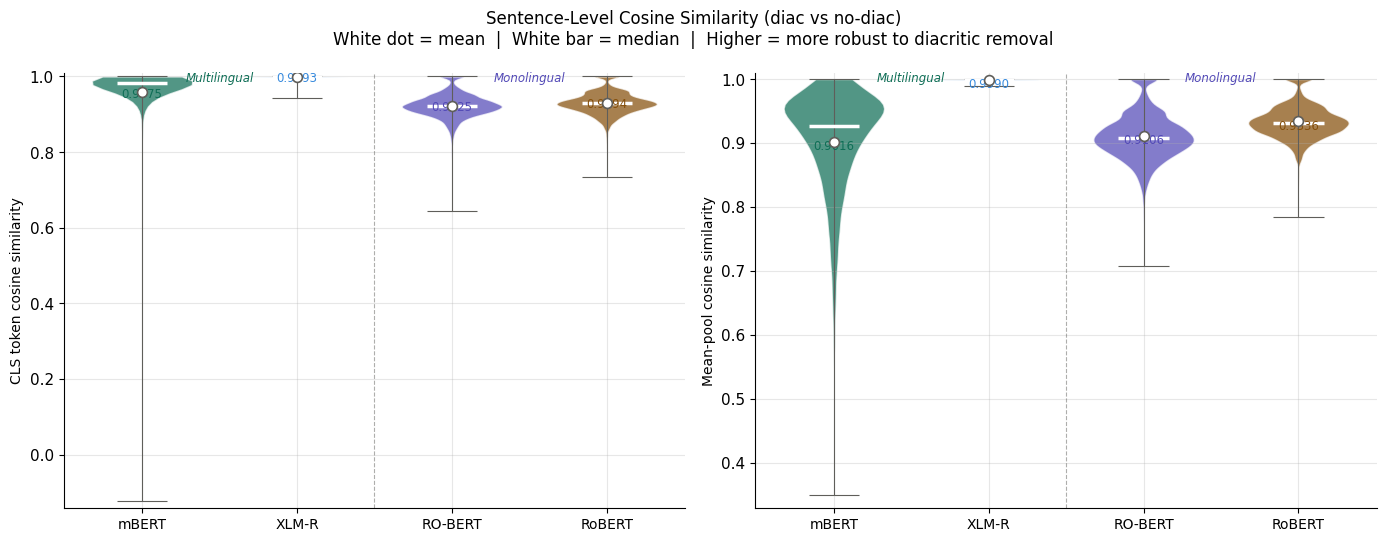

In [30]:

# CLS cosine similarity distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (col, label) in zip(axes, [
    ('cos_cls',  'CLS token cosine similarity'),
    ('cos_mean', 'Mean-pool cosine similarity'),
]):
    data = [sim_df[sim_df['model']==m][col].values for m in MODEL_ORDER]
    parts = ax.violinplot(data, positions=range(4),
                          showmedians=True, showextrema=True, widths=0.65)
    for pc, m in zip(parts['bodies'], MODEL_ORDER):
        pc.set_facecolor(MODEL_COLORS[m]); pc.set_alpha(0.72); pc.set_edgecolor('white')
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2.5)
    for k in ['cmins','cmaxes','cbars']:
        parts[k].set_color(GRAY); parts[k].set_linewidth(0.8)

    means = [sim_df[sim_df['model']==m][col].mean() for m in MODEL_ORDER]
    ax.scatter(range(4), means, color='white', s=50, zorder=5,
               edgecolors=GRAY, linewidths=1.2)
    for i, (m, mn) in enumerate(zip(MODEL_ORDER, means)):
        ax.text(i, mn - 0.012, f'{mn:.4f}', ha='center', fontsize=8.5,
                color=MODEL_COLORS[m], fontweight='500')

    ax.set_xticks(range(4))
    ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_ylim(sim_df[col].min() - 0.02, 1.01)
    ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)
    ax.text(0.5, 0.98, 'Multilingual', ha='center', transform=ax.get_xaxis_transform(),
            color=TEAL, fontsize=8.5, style='italic')
    ax.text(2.5, 0.98, 'Monolingual', ha='center', transform=ax.get_xaxis_transform(),
            color=PURPLE, fontsize=8.5, style='italic')

fig.suptitle(
    'Sentence-Level Cosine Similarity (diac vs no-diac)\n'
    'White dot = mean  |  White bar = median  |  Higher = more robust to diacritic removal',
    fontsize=12, fontweight='500'
)
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ2}/rq2_fig1_cls_violin.png', dpi=150, bbox_inches='tight')
plt.show()



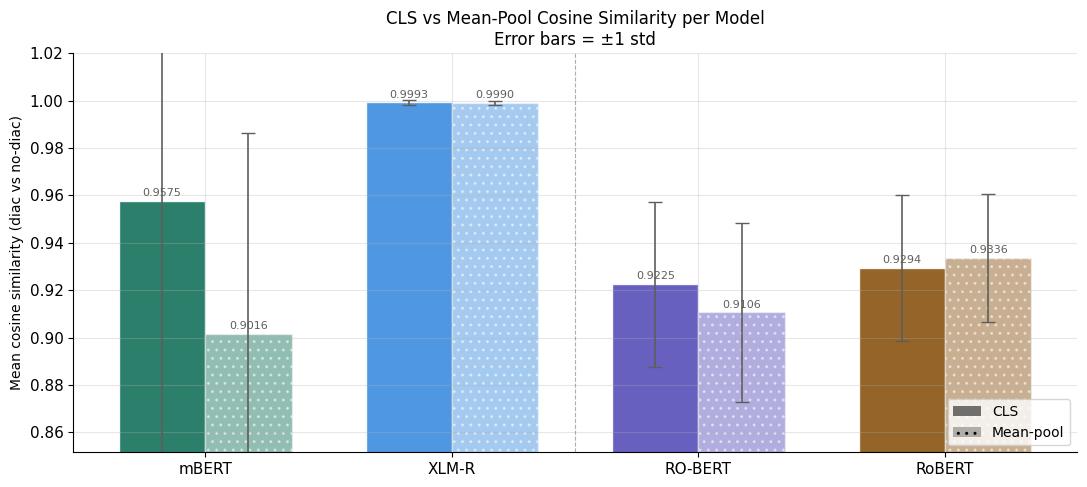

In [31]:
# CLS vs mean-pool bar comparison


fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(4); w = 0.35

cls_means  = [sim_df[sim_df['model']==m]['cos_cls'].mean()  for m in MODEL_ORDER]
mean_means = [sim_df[sim_df['model']==m]['cos_mean'].mean() for m in MODEL_ORDER]
cls_stds   = [sim_df[sim_df['model']==m]['cos_cls'].std()   for m in MODEL_ORDER]
mean_stds  = [sim_df[sim_df['model']==m]['cos_mean'].std()  for m in MODEL_ORDER]

b1 = ax.bar(x - w/2, cls_means,  w, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
            alpha=0.88, edgecolor='white', label='CLS embedding')
b2 = ax.bar(x + w/2, mean_means, w, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
            alpha=0.45, edgecolor='white', hatch='..', label='Mean-pool embedding')
ax.errorbar(x-w/2, cls_means,  yerr=cls_stds,  fmt='none', color=GRAY, capsize=5, lw=1.2)
ax.errorbar(x+w/2, mean_means, yerr=mean_stds, fmt='none', color=GRAY, capsize=5, lw=1.2)

for bars, vals in [(b1, cls_means), (b2, mean_means)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.4f}', ha='center', fontsize=8, color=GRAY)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=11)
ax.set_ylabel('Mean cosine similarity (diac vs no-diac)', fontsize=10)
ax.set_ylim(min(cls_means+mean_means) - 0.05, 1.02)
ax.set_title('CLS vs Mean-Pool Cosine Similarity per Model\n'
             'Error bars = ±1 std', fontsize=12)
ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)
ax.legend(handles=[
    mpatches.Patch(facecolor=GRAY, alpha=0.88, label='CLS'),
    mpatches.Patch(facecolor=GRAY, alpha=0.45, hatch='..', label='Mean-pool'),
], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ2}/rq2_fig2_cls_vs_mean.png', dpi=150, bbox_inches='tight')
plt.show()


---
##  Word-Level Focus-Word Distance

Sentence-level cosine similarity aggregates over the whole sequence.  
Here we zoom into **minimal pairs** — Romanian words where diacritic removal changes meaning or POS and compare the contextual embedding of the focus word in both variants.

In [32]:
# Minimal pairs: word-level embedding distance

# Manually curated minimal pairs with disambiguating sentences
MINIMAL_PAIRS = [
    ('O fată frumoasă merge spre bibliotecă.',
     'O fata frumoasa merge spre biblioteca.',
     'fată', 'fata', 'N: girl (indef.) → girl (def.)'),

    ('Eu cânt la pian în fiecare seară.',
     'Eu cant la pian in fiecare seara.',
     'cânt', 'cant', 'V: I sing / N: a chant'),

    ('România este o țară frumoasă.',
     'Romania este o tara frumoasa.',
     'țară', 'tara', 'N: country / proper noun'),

    ('Pâinea proaspătă mirosea îmbietor.',
     'Painea proaspata mirosea imbietor.',
     'pâinea', 'painea', 'N: the bread (def.)'),

    ('Studenții și-au finalizat tezele de licență.',
     'Studentii si-au finalizat tezele de licenta.',
     'studenții', 'studentii', 'N: the students (def. pl.)'),

    ('Calitatea mâncării este excepțională.',
     'Calitatea mancarii este exceptionala.',
     'mâncării', 'mancarii', 'N: food (gen. def.)'),

    ('Sunt mulțumit de produsul achiziționat.',
     'Sunt multumit de produsul achizitionat.',
     'mulțumit', 'multumit', 'ADJ: satisfied'),

    ('Orașul vechi are multe clădiri istorice.',
     'Orasul vechi are multe cladiri istorice.',
     'orașul', 'orasul', 'N: the city (def.)'),

    ('Guvernul a adoptat noi reglementări privind mediul.',
     'Guvernul a adoptat noi reglementari privind mediul.',
     'reglementări', 'reglementari', 'N: regulations (pl.)'),

    ('Înțelegerea dintre cele două țări a fost semnată.',
     'Intelegerea dintre cele doua tari a fost semnata.',
     'înțelegerea', 'intelegerea', 'N: understanding (def.)'),

    ('Vara aceasta a fost extrem de călduroasă.',
     'Vara aceasta a fost extrem de calduroasa.',
     'călduroasă', 'calduroasa', 'ADJ: hot/warm'),
]

word_dist_rows = []

for sent_d, sent_nd, word_d, word_nd, gloss in MINIMAL_PAIRS:
    # Character offsets in each variant
    start_d  = sent_d.lower().find(word_d.lower())
    start_nd = sent_nd.lower().find(word_nd.lower())

    if start_d == -1 or start_nd == -1:
        continue

    end_d  = start_d  + len(word_d)
    end_nd = start_nd + len(word_nd)

    for tag in MODEL_ORDER:
        emb_d  = get_target_word_embedding(sent_d,  start_d,  end_d,  tag)
        emb_nd = get_target_word_embedding(sent_nd, start_nd, end_nd, tag)

        if emb_d is None or emb_nd is None:
            cos_d, dist = float('nan'), float('nan')
        else:
            cos_d  = float(cosine_similarity(emb_d.reshape(1,-1), emb_nd.reshape(1,-1))[0,0])
            dist   = 1.0 - cos_d

        word_dist_rows.append({
            'word_diac':  word_d,
            'word_nodiac': word_nd,
            'gloss':      gloss,
            'model':      tag,
            'display':    MODEL_DISPLAY[tag],
            'family':     MODEL_FAMILY[tag],
            'cos_sim':    round(cos_d,  5),
            'cos_dist':   round(dist,   5),
        })

word_df = pd.DataFrame(word_dist_rows).dropna()

print('Focus-word cosine distance (diac vs no-diac):  higher = more sensitive')
print('='*62)
print(f'{"Model":12} {"Mean dist":>10} {"Std":>8} {"Max":>8}')
print('-'*62)
for tag in MODEL_ORDER:
    sub = word_df[word_df['model']==tag]['cos_dist']
    print(f'  {MODEL_DISPLAY[tag]:10} {sub.mean():>10.5f} {sub.std():>8.5f} {sub.max():>8.5f}')
print('='*62)

Focus-word cosine distance (diac vs no-diac):  higher = more sensitive
Model         Mean dist      Std      Max
--------------------------------------------------------------
  mBERT         0.26422  0.13687  0.47703
  XLM-R         0.00599  0.00318  0.00998
  RO-BERT       0.17808  0.05942  0.26925
  RoBERT        0.08364  0.03367  0.15664


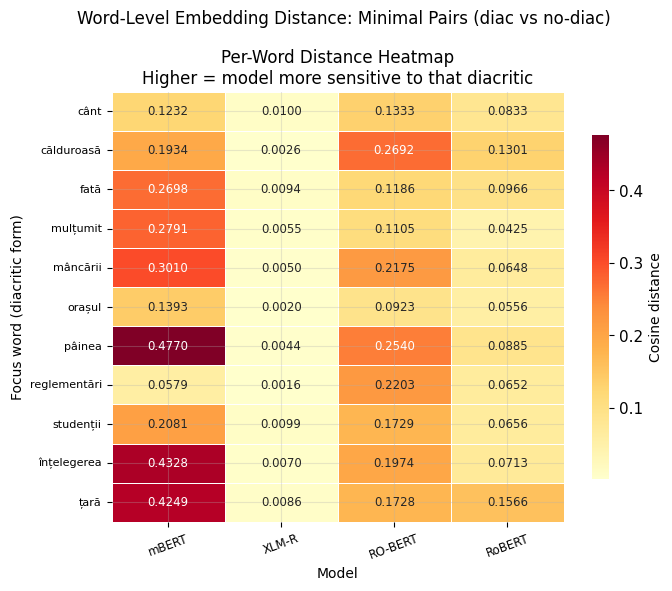

In [33]:
# Word-level distance — strip chart + per-word heatmap

# fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig, ax = plt.subplots(figsize=(7, 6))
# # ── Panel A: Strip chart ──────────────────────────────────────────────────────
# ax = axes[0]
# rng = np.random.default_rng(SEED)
# for _, row in word_df.iterrows():
#     xi = MODEL_ORDER.index(row['model']) + rng.uniform(-0.18, 0.18)
#     ax.scatter(xi, row['cos_dist'],
#                color=MODEL_COLORS[row['model']], alpha=0.55, s=40, edgecolors='none')

# for i, tag in enumerate(MODEL_ORDER):
#     sub = word_df[word_df['model']==tag]['cos_dist']
#     ax.errorbar(i, sub.mean(), yerr=sub.std(), fmt='D',
#                 color='black', markersize=8, capsize=6, lw=2, zorder=5)

# ax.set_xticks(range(4))
# ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], fontsize=10)
# ax.set_ylabel('Cosine distance (1 − similarity)')
# ax.set_title('A — Focus-word Distance per Model\n'
#              'Diamonds = mean±std  |  Dots = individual word pairs')
# ax.axvline(1.5, color=GRAY, lw=0.8, ls='--', alpha=0.5)
# ax.text(0.5, 0.98, 'Multilingual', ha='center', transform=ax.get_xaxis_transform(),
#         color=TEAL, fontsize=8.5, style='italic')
# ax.text(2.5, 0.98, 'Monolingual', ha='center', transform=ax.get_xaxis_transform(),
#         color=PURPLE, fontsize=8.5, style='italic')

# ── Panel B: Heatmap per word × model ────────────────────────────────────────
# ax = axes[1]
pivot = word_df.pivot_table(
    index='word_diac', columns='display', values='cos_dist', aggfunc='mean'
)
col_order = [MODEL_DISPLAY[m] for m in MODEL_ORDER if MODEL_DISPLAY[m] in pivot.columns]
pivot = pivot[col_order]

sns.heatmap(
    pivot, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Cosine distance'},
    annot_kws={'fontsize': 8.5}
)
ax.set_title('Per-Word Distance Heatmap\nHigher = model more sensitive to that diacritic')
ax.set_xlabel('Model'); ax.set_ylabel('Focus word (diacritic form)')
ax.tick_params(axis='x', rotation=20, labelsize=8.5)
ax.tick_params(axis='y', rotation=0, labelsize=8)

fig.suptitle('Word-Level Embedding Distance: Minimal Pairs (diac vs no-diac)',
             fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ2}/rq2_fig3_word_level_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [34]:
# Layer-wise cosine similarity (50-sentence subset for speed)
#
# For each of the 13 hidden states (embedding layer + 12 transformer blocks),
# compute mean CLS cosine similarity across all sentence pairs.

N_LAYER_SUBSET = min(50, N)
N_LAYERS = 13
layer_sim_store = {}

for tag in MODEL_ORDER:
    layer_sims = np.zeros(N_LAYERS)

    for i in tqdm(range(N_LAYER_SUBSET), desc=f'{MODEL_DISPLAY[tag]:10} layers', leave=False):
        layers_d  = get_layer_embeddings(TEXTS_DIAC[i],   tag, N_LAYERS)
        layers_nd = get_layer_embeddings(TEXTS_NODIAC[i], tag, N_LAYERS)

        for l in range(N_LAYERS):
            sim = float(cosine_similarity(
                layers_d[l].reshape(1,-1), layers_nd[l].reshape(1,-1)
            )[0,0])
            layer_sims[l] += sim

    layer_sim_store[tag] = layer_sims / N_LAYER_SUBSET
    print(f'  ✓ {MODEL_DISPLAY[tag]}  |  last-layer mean: {layer_sim_store[tag][-1]:.5f}')

layer_df = pd.DataFrame(
    {MODEL_DISPLAY[t]: layer_sim_store[t] for t in MODEL_ORDER},
    index=[f'layer_{i}' for i in range(N_LAYERS)]
)
layer_df.to_csv(f'{ANALYSIS_FOLDER}/rq2_layer_wise_sims.csv', index=False)
print('\nLayer-wise sim table:')
print(layer_df.round(5).to_string())

  ✓ mBERT  |  last-layer mean: 0.94793


  ✓ XLM-R  |  last-layer mean: 0.99928


  ✓ RO-BERT  |  last-layer mean: 0.92124


  ✓ RoBERT  |  last-layer mean: 0.92571

Layer-wise sim table:
            mBERT    XLM-R  RO-BERT   RoBERT
layer_0   1.00000  1.00000  1.00000  1.00000
layer_1   0.99965  0.99997  0.99983  0.99963
layer_2   0.99992  0.99999  0.99928  0.99955
layer_3   0.99995  1.00000  0.99936  0.99774
layer_4   0.99985  1.00000  0.99776  0.99671
layer_5   0.98453  0.99999  0.99249  0.98872
layer_6   0.97826  1.00000  0.99125  0.98741
layer_7   0.97227  1.00000  0.98886  0.97269
layer_8   0.96319  1.00000  0.98549  0.96789
layer_9   0.96655  1.00000  0.98319  0.97200
layer_10  0.96276  1.00000  0.97737  0.97659
layer_11  0.96482  0.99998  0.96574  0.96954
layer_12  0.94793  0.99928  0.92124  0.92571


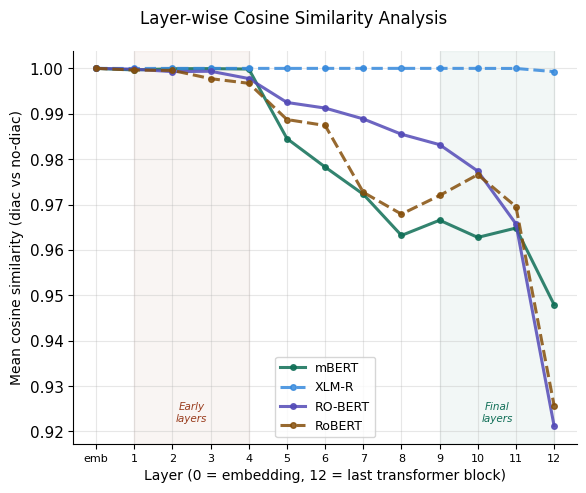


Layer where cosine sim is lowest (most affected) per model:
  mBERT     : layer 12  (sim=0.94793)
  XLM-R     : layer 12  (sim=0.99928)
  RO-BERT   : layer 12  (sim=0.92124)
  RoBERT    : layer 12  (sim=0.92571)


In [35]:
#  Layer-wise curves + mono/multi delta
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(N_LAYERS)
layer_labels = ['emb'] + [str(l) for l in range(1, N_LAYERS)]
line_styles  = {'mbert': '-', 'xlmr': '--', 'ro_bert': '-', 'robert': '--'}

for tag in MODEL_ORDER:
    ax.plot(x, layer_sim_store[tag],
            color=MODEL_COLORS[tag], lw=2.2,
            linestyle=line_styles[tag],
            marker='o', markersize=4, alpha=0.85,
            label=MODEL_DISPLAY[tag])

ax.set_xticks(x); ax.set_xticklabels(layer_labels, fontsize=8)
ax.set_xlabel('Layer (0 = embedding, 12 = last transformer block)')
ax.set_ylabel('Mean cosine similarity (diac vs no-diac)')
ax.legend(fontsize=9)
ax.axvspan(1, 4,  alpha=0.05, color=CORAL)
ax.axvspan(9, 12, alpha=0.05, color=TEAL)
ax.text(2.5, ax.get_ylim()[0]+0.005, 'Early\nlayers', ha='center',
        fontsize=7.5, color=CORAL, style='italic')
ax.text(10.5, ax.get_ylim()[0]+0.005, 'Final\nlayers', ha='center',
        fontsize=7.5, color=TEAL, style='italic')


fig.suptitle('Layer-wise Cosine Similarity Analysis',
             fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ2}/rq2_fig6_layerwise.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nLayer where cosine sim is lowest (most affected) per model:')
for tag in MODEL_ORDER:
    sims = layer_sim_store[tag]
    worst = int(sims[1:].argmin()) + 1
    print(f'  {MODEL_DISPLAY[tag]:10}: layer {worst}  (sim={sims[worst]:.5f})')

---
## Cross-Model Agreement (Kendall τ)

Cross-model Kendall τ rank correlation:
          mBERT   XLM-R  RO-BERT  RoBERT
mBERT    1.0000  0.2916   0.2929  0.3033
XLM-R    0.2916  1.0000   0.3413  0.3451
RO-BERT  0.2929  0.3413   1.0000  0.6034
RoBERT   0.3033  0.3451   0.6034  1.0000


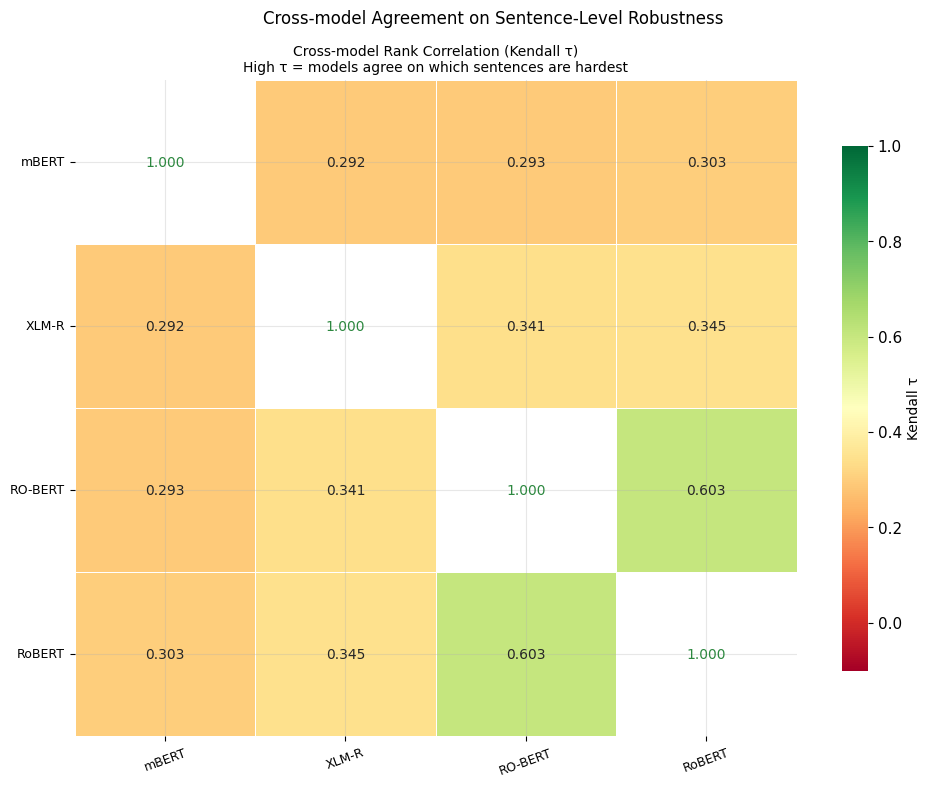


5 hardest sentences (lowest mean cosine sim across all models):
  [7359] sim=0.6679  n_diac=11  "Incercase de trei ori sa adoarma si de trei ori se trezise din toropeala, inabus"
  [3570] sim=0.6679  n_diac=20  "Era o singuratate desavirsita; nu se vedeau inca fumuri de sate, si, in finaturi"
  [1530] sim=0.6704  n_diac=17  "Ganditi-va la un tanar neinvatat cu virtutea rabdarii, care n-a trebuit sa trans"
  [5013] sim=0.6746  n_diac=21  "Muncitorii detasati reprezinta in jur de 1% din forta de munca din Vest, dar Aus"
  [6582] sim=0.6755  n_diac=19  "Flacaii nostri erau indrazneti si smecheri, comedie mare. De multe ori dadeau in"


In [36]:
#  Cross-model rank correlation + hardest sentences
# Rank sentences by CLS cosine sim (ascending = harder = lower sim)
rank_matrix = pd.DataFrame({
    MODEL_DISPLAY[t]: sim_df[sim_df['model']==t]['cos_cls'].rank(ascending=True).values
    for t in MODEL_ORDER
})

n_models = len(MODEL_ORDER)
tau_matrix = np.zeros((n_models, n_models))
for i, ti in enumerate(MODEL_ORDER):
    for j, tj in enumerate(MODEL_ORDER):
        tau, _ = kendalltau(rank_matrix[MODEL_DISPLAY[ti]].values,
                            rank_matrix[MODEL_DISPLAY[tj]].values)
        tau_matrix[i,j] = tau

display_labels = [MODEL_DISPLAY[t] for t in MODEL_ORDER]
tau_df = pd.DataFrame(tau_matrix.round(4), index=display_labels, columns=display_labels)

print('Cross-model Kendall τ rank correlation:')
print(tau_df.to_string())

# Hardest sentences
sim_df['mean_cos_all'] = sim_df.groupby('sent_idx')['cos_cls'].transform('mean')
hardest_idxs = sim_df.drop_duplicates('sent_idx').nsmallest(5, 'mean_cos_all')['sent_idx'].values

fig, ax=plt.subplots(figsize=(10, 8))
# Kendall τ heatmap ────────────────────────────────────────────────

mask = np.eye(n_models, dtype=bool)
sns.heatmap(tau_df, ax=ax, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-0.1, vmax=1.0, mask=mask,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Kendall τ'},
            annot_kws={'fontsize': 10})
for i in range(n_models):
    ax.text(i+0.5, i+0.5, '1.000', ha='center', va='center',
            fontsize=10, color='#2D8840', fontweight='500')
ax.set_title('Cross-model Rank Correlation (Kendall τ)\n'
             'High τ = models agree on which sentences are hardest', fontsize=10)
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)


fig.suptitle('Cross-model Agreement on Sentence-Level Robustness',
             fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig(f'{FIG_FOLDER_RQ2}/rq2_fig8_cross_model.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n5 hardest sentences (lowest mean cosine sim across all models):')
for idx in hardest_idxs:
    mean_sim = sim_df[sim_df['sent_idx']==idx]['cos_cls'].mean()
    nd_txt   = str(TEXTS_NODIAC[idx])[:80]
    n_diac   = df_filtered.iloc[idx]['n_diac_restored']
    print(f'  [{idx:3d}] sim={mean_sim:.4f}  n_diac={n_diac}  "{nd_txt}"')

In [37]:
# Complete results table + 5 key findings
corr_rows = []
for tag in MODEL_ORDER:
    sub = sim_df[sim_df['model'] == tag]
    x_v = sub['n_diac'].values
    y_v = sub['cos_cls'].values
    r_p, p_p = pearsonr(x_v, y_v)
    r_s, p_s = spearmanr(x_v, y_v)
    corr_rows.append({
        'model': MODEL_DISPLAY[tag], 'family': MODEL_FAMILY[tag],
        'pearson_r': round(r_p, 4), 'pearson_p': round(p_p, 4),
        'spearman_r': round(r_s, 4), 'spearman_p': round(p_s, 4),
        'significant': (p_p < 0.05) or (p_s < 0.05),
    })
corr_df = pd.DataFrame(corr_rows)
final_rows = []
for tag in MODEL_ORDER:
    sub = sim_df[sim_df['model']==tag]
    final_rows.append({
        'Model':                MODEL_DISPLAY[tag],
        'Family':               MODEL_FAMILY[tag],
        'CLS sim mean':         round(sub['cos_cls'].mean(),  5),
        'CLS sim std':          round(sub['cos_cls'].std(),   5),
        'CLS sim min':          round(sub['cos_cls'].min(),   5),
        'Mean-pool sim':        round(sub['cos_mean'].mean(), 5),
        'Focus-word dist':      round(word_df[word_df['model']==tag]['cos_dist'].mean(), 5),
        'Pearson r (density)':  corr_df[corr_df['model']==MODEL_DISPLAY[tag]]['pearson_r'].values[0],
        'Layer of min sim':     int(layer_sim_store[tag][1:].argmin()) + 1,
    })

final_df = pd.DataFrame(final_rows)
final_df.to_csv(f'{ANALYSIS_FOLDER}/rq2_final_results.csv', index=False)


print(final_df.to_string(index=False))
print('═'*78)


  Model       Family  CLS sim mean  CLS sim std  CLS sim min  Mean-pool sim  Focus-word dist  Pearson r (density)  Layer of min sim
  mBERT Multilingual       0.95753      0.11909     -0.12218        0.90159          0.26422              -0.1873                12
  XLM-R Multilingual       0.99926      0.00099      0.94291        0.99896          0.00599              -0.0436                12
RO-BERT  Monolingual       0.92253      0.03486      0.64457        0.91060          0.17808              -0.1007                12
 RoBERT  Monolingual       0.92944      0.03077      0.73417        0.93360          0.08364              -0.1211                12
══════════════════════════════════════════════════════════════════════════════
